In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../'))
from scripts.forecast_models import optimize_portfolio, run_portfolio_backtest

# 1. Load your clean historical returns dataset
returns_df = pd.read_csv('../data/processed/daily_returns.csv', index_col=0, parse_dates=True)
cov_matrix = returns_df.cov()

# 2. Re-verify your optimized weights from your Task 4 calculations
tsla_forecast = pd.read_csv('../data/processed/tsla_future_forecast.csv', header=None, names=['Date', 'Price'])
tsla_forecast['Price'] = pd.to_numeric(tsla_forecast['Price'], errors='coerce')
tsla_forecast = tsla_forecast.dropna().reset_index(drop=True)

tsla_expected_return = (tsla_forecast['Price'].iloc[-1] - tsla_forecast['Price'].iloc[0]) / tsla_forecast['Price'].iloc[0]
spy_expected_return = returns_df['SPY'].mean() * 252
bnd_expected_return = returns_df['BND'].mean() * 252
expected_returns = np.array([bnd_expected_return, spy_expected_return, tsla_expected_return])

# Generate Maximum Sharpe optimal allocation vector
max_sharpe_weights = optimize_portfolio(expected_returns, cov_matrix, objective='sharpe')

# 3. Spin up the backtester across your out-of-sample timeline
curves, metrics_table = run_portfolio_backtest(returns_df, max_sharpe_weights)

print("=== BACKTEST PERFORMANCE OVERVIEW ===")
display(metrics_table)

=== BACKTEST PERFORMANCE OVERVIEW ===


,Optimized Strategy,Passive Benchmark (60/40)
Total Return,32.36%,13.99%
Annualized Return,30.96%,13.42%
Sharpe Ratio,1.69,1.16
Max Drawdown,-10.83%,-8.61%


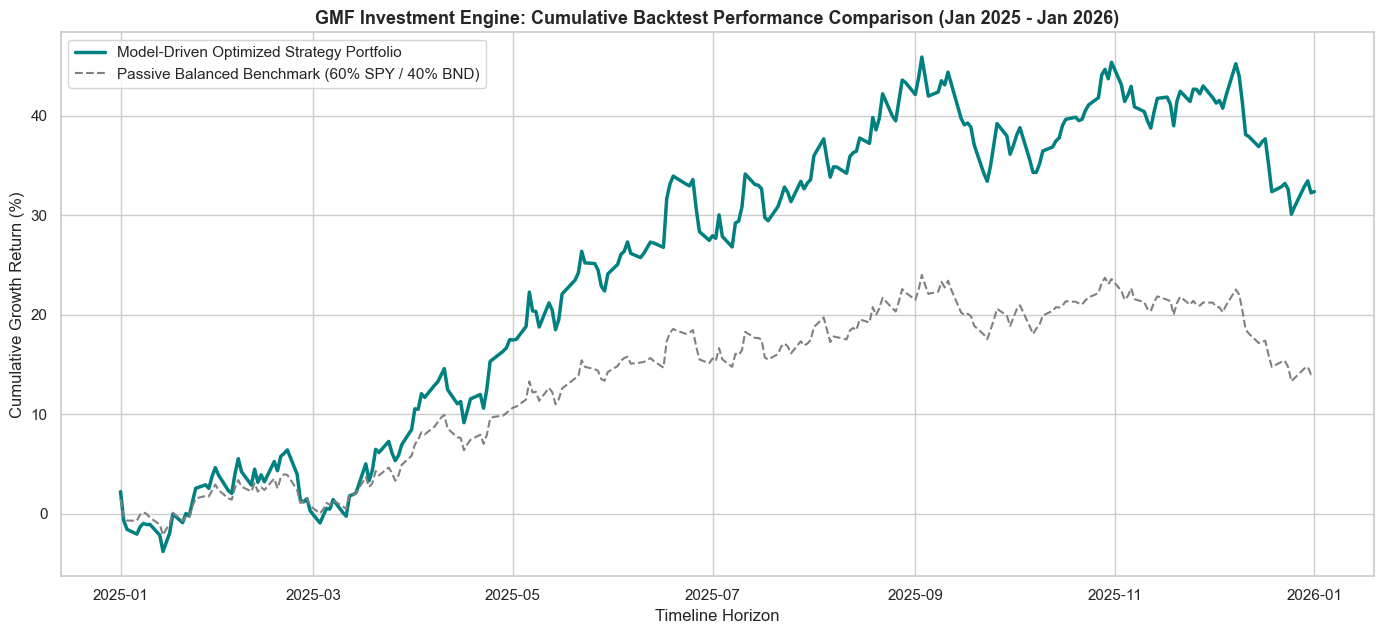

In [2]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6.5))

plt.plot(curves.index, curves['Strategy'] * 100, label="Model-Driven Optimized Strategy Portfolio", color="emerald" if 'emerald' in plt.colormaps else "teal", linewidth=2.5)
plt.plot(curves.index, curves['Benchmark'] * 100, label="Passive Balanced Benchmark (60% SPY / 40% BND)", color="grey", linestyle="--", linewidth=1.5)

plt.title("GMF Investment Engine: Cumulative Backtest Performance Comparison (Jan 2025 - Jan 2026)", fontsize=13, fontweight='bold')
plt.ylabel("Cumulative Growth Return (%)")
plt.xlabel("Timeline Horizon")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()